# Bayesian Linear Regression with MCMC
## From Posteriors to Samplers: Metropolis-Hastings vs Hamiltonian Monte Carlo

---

**The Problem:** Given noisy observations $y_i = m x_i + c + \eta_i$ where $\eta_i \sim \mathcal{N}(0, \sigma^2)$, can we infer the slope $m$ and intercept $c$?

Instead of finding a single best-fit line, we'll recover the **full posterior distribution** $P(m, c \mid \mathbf{y})$ — giving us not just estimates, but uncertainties.

We'll build two samplers from scratch — **Metropolis-Hastings** and **Hamiltonian Monte Carlo** — and see how they compare.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#0e1117',
    'axes.edgecolor': '#333846',
    'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#1c2030',
    'grid.alpha': 0.6,
    'font.family': 'monospace',
    'font.size': 11,
    'axes.grid': True,
    'figure.dpi': 130,
})

# Color palette
AMBER   = '#f59e0b'
CYAN    = '#06b6d4'
RED     = '#ef4444'
GREEN   = '#4ade80'
PURPLE  = '#a78bfa'
PINK    = '#f472b6'
SLATE   = '#64748b'
WHITE   = '#e2e8f0'

---
## 1. Generate the Dataset

Our **ground truth** model:

$$y_i = m_{\rm true} \cdot x_i + c_{\rm true} + \eta_i, \quad \eta_i \sim \mathcal{N}(0, \sigma^2)$$

In [4]:
np.random.seed(100)  # for reproducibility

# ── Ground truth parameters ────────────────────────────
m_true = 2.5       # slope
c_true = -0.8      # intercept
sigma  = 1.2       # noise std
N_data = 10        # data points

# ── Generate data ──────────────────────────────────────
x_data = np.sort(np.random.uniform(-3, 3, N_data))
noise  = np.random.normal(0, sigma, N_data)
y_data = m_true * x_data + c_true + noise

print(f'Ground truth:  m = {m_true},  c = {c_true},  σ = {sigma}')
print(f'Data points:   {N_data}')

Ground truth:  m = 2.5,  c = -0.8,  σ = 1.2
Data points:   10


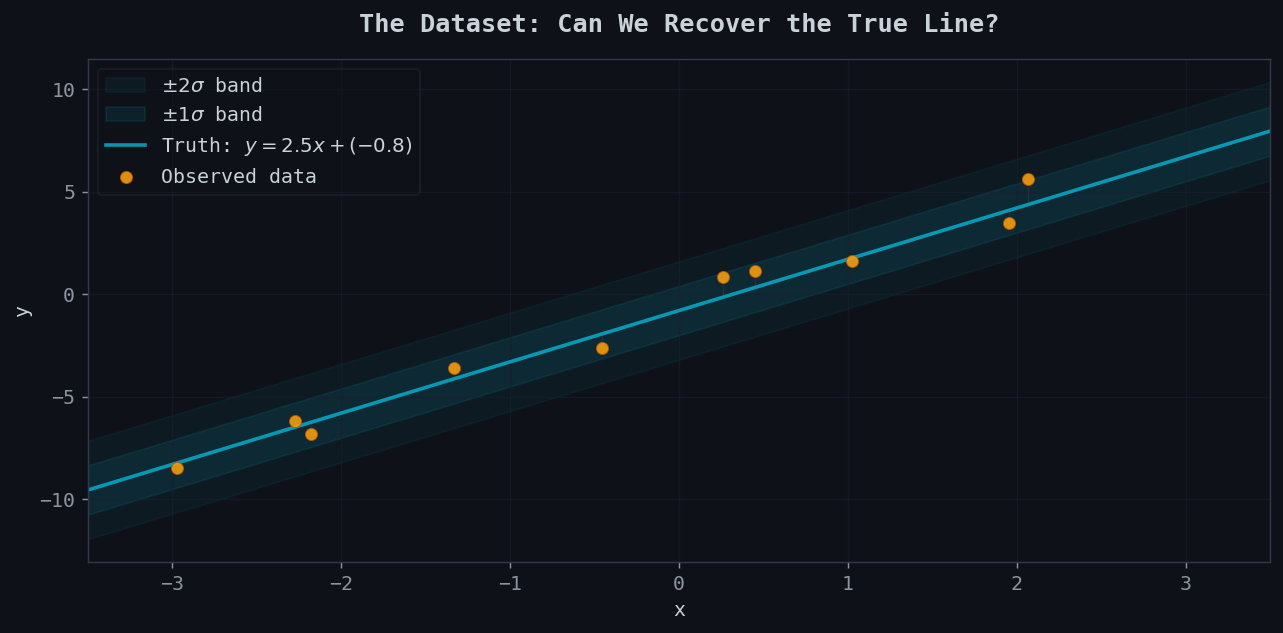

In [5]:
# ── Visualise the dataset ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Confidence band
x_line = np.linspace(-3.5, 3.5, 200)
y_line = m_true * x_line + c_true
ax.fill_between(x_line, y_line - 2*sigma, y_line + 2*sigma,
                color=CYAN, alpha=0.06, label=r'$\pm 2\sigma$ band')
ax.fill_between(x_line, y_line - sigma, y_line + sigma,
                color=CYAN, alpha=0.1, label=r'$\pm 1\sigma$ band')

# True line
ax.plot(x_line, y_line, color=CYAN, lw=2, alpha=0.8,
        label=f'Truth: $y = {m_true}x + ({c_true})$')

# Data with error-like scatter
ax.scatter(x_data, y_data, c=AMBER, s=45, zorder=5, edgecolors='#b45309',
           linewidths=0.5, alpha=0.9, label='Observed data')

# Residual whiskers
for xi, yi in zip(x_data, y_data):
    y_pred = m_true * xi + c_true
    ax.plot([xi, xi], [y_pred, yi], color=RED, alpha=0.15, lw=0.8)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('The Dataset: Can We Recover the True Line?', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper left', framealpha=0.3, edgecolor='#333846')
ax.set_xlim(-3.5, 3.5)
plt.tight_layout()
plt.show()

---
## 2. The Bayesian Framework

### Likelihood

Each data point is drawn from a Gaussian centred on the model prediction:

$$P(\mathbf{y}, \mathbf{x} \mid m, c, \sigma) = \prod_{i=1}^{N} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left[ -\frac{(y_i - m x_i - c)^2}{2\sigma^2} \right]$$

Taking the log:

$$\ln \mathcal{L} = -\frac{N}{2}\ln(2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^{N} (y_i - m x_i - c)^2$$

### Priors

We use weakly informative (broad) Gaussian priors:

$$m \sim \mathcal{N}(0, 10^2), \quad c \sim \mathcal{N}(0, 10^2)$$

We treat $\sigma$ as **known** (fixed at the true value) to keep the focus on inferring $m$ and $c$.

### Posterior

By **Bayes' theorem**:

$$\boxed{P(m, c \mid \mathbf{y}) \propto \mathcal{L}(\mathbf{y} \mid m, c) \cdot \pi(m) \cdot \pi(c)}$$

The log-posterior (up to a constant) is:

$$\ln P(m, c \mid \mathbf{y}) = -\frac{1}{2\sigma^2}\sum_i (y_i - mx_i - c)^2 - \frac{m^2}{2 \cdot 10^2} - \frac{c^2}{2 \cdot 10^2} + \text{const}$$

This is what we need to evaluate. For HMC we also need its **gradient** with respect to $m$ and $c$:

$$\frac{\partial \ln P}{\partial m} = \frac{1}{\sigma^2} \sum_i x_i(y_i - mx_i - c) - \frac{m}{100}$$

$$\frac{\partial \ln P}{\partial c} = \frac{1}{\sigma^2} \sum_i (y_i - mx_i - c) - \frac{c}{100}$$

In [4]:
# ── Posterior functions ─────────────────────────────────

def log_posterior(theta, x, y, sigma):
    """Log-posterior: log-likelihood + log-prior for (m, c)."""
    m, c = theta
    residuals = y - m * x - c
    log_lik   = -0.5 * np.sum(residuals**2) / sigma**2
    log_prior = -0.5 * (m**2 + c**2) / 100.0   # broad Gaussian prior
    return log_lik + log_prior


def grad_log_posterior(theta, x, y, sigma):
    """Gradient of log-posterior w.r.t. (m, c). Needed for HMC."""
    m, c = theta
    residuals = y - m * x - c
    dlogp_dm = np.sum(x * residuals) / sigma**2 - m / 100.0
    dlogp_dc = np.sum(residuals) / sigma**2     - c / 100.0
    return np.array([dlogp_dm, dlogp_dc])


print('✓ Posterior functions defined')

✓ Posterior functions defined


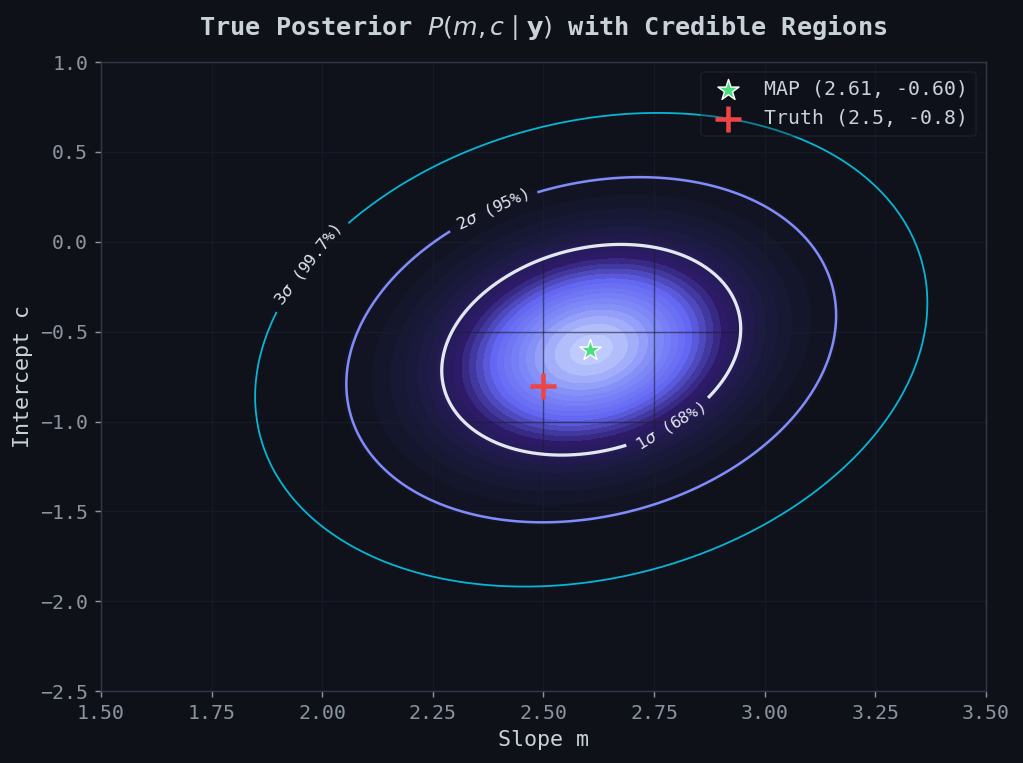

  Truth is at m=2.5, c=-0.8
  MAP  is at m=2.606, c=-0.601
  Offset due to this particular noise realisation — not a bug!


In [5]:
# ── Visualise the true posterior surface ────────────────
m_grid = np.linspace(1.5, 3.5, 200)
c_grid = np.linspace(-2.5, 1.0, 200)
M, C   = np.meshgrid(m_grid, c_grid)
logP   = np.array([[log_posterior([mi, ci], x_data, y_data, sigma)
                     for mi in m_grid] for ci in c_grid])
P_surf = np.exp(logP - logP.max())  # normalised for plotting

# ── Compute proper credible region thresholds ──────────
# Sort density values and find the level that encloses X% of total probability
dm = m_grid[1] - m_grid[0]
dc = c_grid[1] - c_grid[0]
P_total = P_surf.sum() * dm * dc  # numerical integral
P_norm  = P_surf / P_total         # proper normalised PDF

# For each threshold t, the credible region is {P_norm > t}
# and the enclosed mass is sum(P_norm[P_norm > t]) * dm * dc
sorted_p = np.sort(P_norm.ravel())[::-1]
cum_mass = np.cumsum(sorted_p) * dm * dc

def credible_threshold(level):
    idx = np.searchsorted(cum_mass, level)
    idx = min(idx, len(sorted_p) - 1)
    return sorted_p[idx]

t1 = credible_threshold(0.683)  # 1-sigma
t2 = credible_threshold(0.954)  # 2-sigma
t3 = credible_threshold(0.997)  # 3-sigma

fig, ax = plt.subplots(figsize=(8, 6))

# Smooth heatmap background
ax.contourf(M, C, P_norm, levels=30,
            cmap=LinearSegmentedColormap.from_list('',
                  ['#0e1117', '#1a1a3e', '#2d1b69', '#6366f1', '#818cf8', '#c7d2fe']))

# Proper credible region contours
cs = ax.contour(M, C, P_norm, levels=[t3, t2, t1],
                colors=[CYAN, '#818cf8', WHITE], linewidths=[1.0, 1.4, 1.8])
# Manual labels
fmt = {t1: '$1\\sigma$ (68%)', t2: '$2\\sigma$ (95%)', t3: '$3\\sigma$ (99.7%)'}
ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=9, colors=WHITE)

# Mark the MAP (posterior peak)
peak_idx = np.unravel_index(np.argmax(P_surf), P_surf.shape)
m_map, c_map = m_grid[peak_idx[1]], c_grid[peak_idx[0]]
ax.scatter([m_map], [c_map], marker='*', s=150, c=GREEN, edgecolors='white',
           linewidths=0.8, zorder=10, label=f'MAP ({m_map:.2f}, {c_map:.2f})')

# Mark the truth
ax.scatter([m_true], [c_true], marker='+', s=200, c=RED, linewidths=2.5,
           zorder=10, label=f'Truth ({m_true}, {c_true})')

ax.set_xlabel('Slope m', fontsize=12)
ax.set_ylabel('Intercept c', fontsize=12)
ax.set_title('True Posterior $P(m, c \mid \mathbf{y})$ with Credible Regions',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', framealpha=0.3, edgecolor='#333846')
plt.tight_layout()
plt.show()

print(f'  Truth is at m={m_true}, c={c_true}')
print(f'  MAP  is at m={m_map:.3f}, c={c_map:.3f}')
print(f'  Offset due to this particular noise realisation — not a bug!')

---
## 3. Metropolis-Hastings Sampler

The simplest MCMC algorithm. At each step:

1. **Propose** a new point: $\theta^* = \theta_t + \epsilon$, where $\epsilon \sim \mathcal{N}(0, \Sigma_{\text{prop}})$
2. **Compute** the acceptance ratio: $\alpha = \min\left(1, \dfrac{P(\theta^*)}{P(\theta_t)}\right)$
3. **Accept** with probability $\alpha$; otherwise stay at $\theta_t$

No gradient information is used — the sampler stumbles around blindly, guided only by whether the new spot is more or less probable.

In [11]:
def metropolis_hastings(log_post, theta0, n_samples, proposal_std,
                        x, y, sigma, burn_in=500):
    """
    Metropolis-Hastings sampler for 2D parameter space.
    
    Returns:
        chain    : (n_samples, 2) array of accepted samples
        full_chain: full chain including burn-in
        acc_rate : acceptance rate
        proposals: list of (proposed_point, accepted_bool) for visualisation
    """
    dim = len(theta0)
    total = n_samples + burn_in
    chain = np.zeros((total, dim))
    chain[0] = theta0
    accepted = 0
    proposals = []
    
    current_logp = log_post(theta0, x, y, sigma)
    
    for i in range(1, total):
        # Propose
        proposal = chain[i-1] + np.random.normal(0, proposal_std, dim)
        proposed_logp = log_post(proposal, x, y, sigma)
        
        # Accept / reject
        log_alpha = proposed_logp - current_logp
        if np.log(np.random.random()) < log_alpha:
            chain[i] = proposal
            current_logp = proposed_logp
            accepted += 1
            proposals.append((proposal, True))
        else:
            chain[i] = chain[i-1]
            proposals.append((proposal, False))
    
    acc_rate = accepted / total
    return chain[burn_in:], chain, acc_rate, proposals


# ── Run MH ─────────────────────────────────────────────
n_mh = 15000
burn_mh = 2000

mh_samples, mh_full, mh_acc, mh_proposals = metropolis_hastings(
    log_posterior,
    theta0=np.array([1.55, 0.9]),   # start far from truth
    n_samples=n_mh,
    proposal_std=0.15,
    x=x_data, y=y_data, sigma=sigma,
    burn_in=burn_mh
)

print(f'Metropolis-Hastings')
print(f'  Samples (post burn-in): {n_mh}')
print(f'  Burn-in:                {burn_mh}')
print(f'  Acceptance rate:        {mh_acc:.1%}')
print(f'  m estimate:             {np.mean(mh_samples[:,0]):.3f} ± {np.std(mh_samples[:,0]):.3f}')
print(f'  c estimate:             {np.mean(mh_samples[:,1]):.3f} ± {np.std(mh_samples[:,1]):.3f}')

Metropolis-Hastings
  Samples (post burn-in): 15000
  Burn-in:                2000
  Acceptance rate:        74.4%
  m estimate:             2.610 ± 0.217
  c estimate:             -0.603 ± 0.373


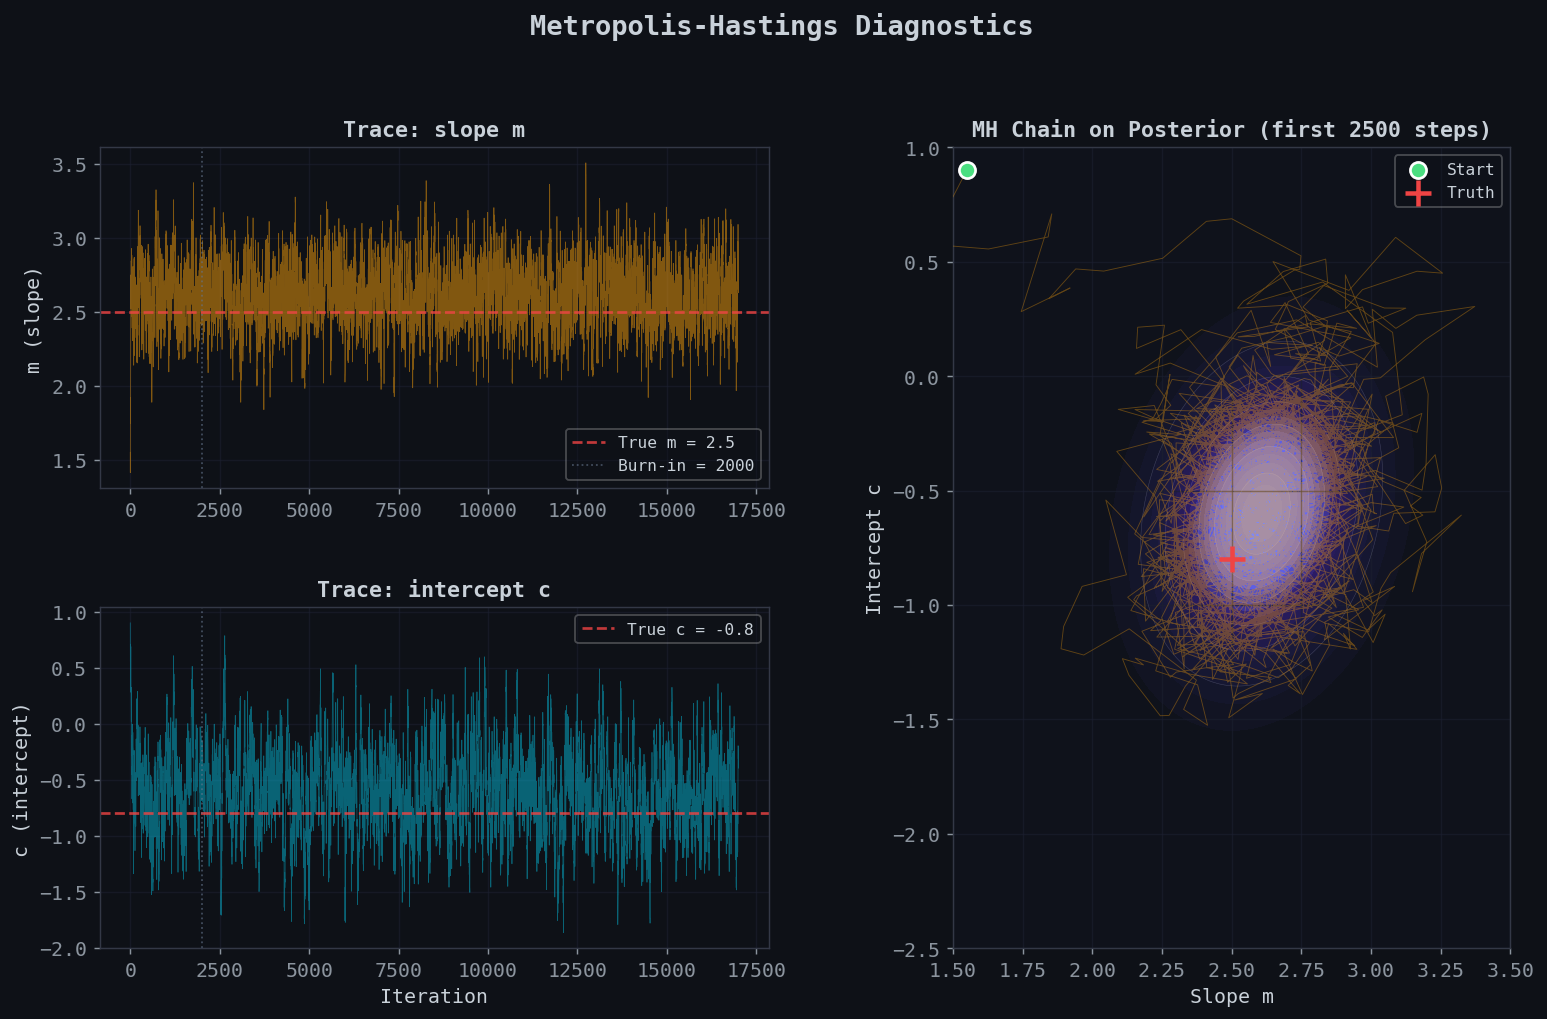

In [12]:
# ── MH Diagnostics: Trace Plots + Chain on Posterior ───

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.2, 1], hspace=0.35, wspace=0.3)

# ── Trace plot: m ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(mh_full[:, 0], color=AMBER, alpha=0.5, lw=0.4)
ax1.axhline(m_true, color=RED, ls='--', lw=1.5, alpha=0.8, label=f'True m = {m_true}')
ax1.axvline(burn_mh, color=SLATE, ls=':', lw=1, alpha=0.6, label=f'Burn-in = {burn_mh}')
ax1.set_ylabel('m (slope)')
ax1.set_title('Trace: slope m', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, framealpha=0.3)

# ── Trace plot: c ──
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(mh_full[:, 1], color=CYAN, alpha=0.5, lw=0.4)
ax2.axhline(c_true, color=RED, ls='--', lw=1.5, alpha=0.8, label=f'True c = {c_true}')
ax2.axvline(burn_mh, color=SLATE, ls=':', lw=1, alpha=0.6)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('c (intercept)')
ax2.set_title('Trace: intercept c', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, framealpha=0.3)

# ── Chain on posterior contour ──
ax3 = fig.add_subplot(gs[:, 1])
ax3.contourf(M, C, P_surf, levels=20,
             cmap=LinearSegmentedColormap.from_list('',
                   ['#0e1117', '#1a1a3e', '#2d1b69', '#6366f1', '#818cf8']))
ax3.contour(M, C, P_surf, levels=6, colors=WHITE, linewidths=0.3, alpha=0.2)

# Plot first 2000 steps of chain (including burn-in) to show convergence
n_show = 2500
ax3.plot(mh_full[:n_show, 0], mh_full[:n_show, 1],
         color=AMBER, alpha=0.35, lw=0.5, zorder=3)
ax3.scatter(mh_full[0, 0], mh_full[0, 1], marker='o', s=80,
            c=GREEN, edgecolors='white', linewidths=1.5, zorder=10, label='Start')
ax3.scatter([m_true], [c_true], marker='+', s=200, c=RED,
            linewidths=2.5, zorder=10, label='Truth')

ax3.set_xlabel('Slope m')
ax3.set_ylabel('Intercept c')
ax3.set_title(f'MH Chain on Posterior (first {n_show} steps)',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9, framealpha=0.3, loc='upper right')
ax3.set_xlim(m_grid[0], m_grid[-1])
ax3.set_ylim(c_grid[0], c_grid[-1])

fig.suptitle('Metropolis-Hastings Diagnostics', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Hamiltonian Monte Carlo (HMC)

HMC treats the parameters as **position** $q = (m, c)$ and introduces auxiliary **momentum** $p \sim \mathcal{N}(0, I)$.

The Hamiltonian:

$$H(q, p) = \underbrace{-\ln P(q \mid \mathbf{y})}_{U(q) \text{ (potential)}} + \underbrace{\frac{1}{2}p^T p}_{K(p) \text{ (kinetic)}}$$

### The Leapfrog Integrator

We simulate Hamiltonian dynamics with the **leapfrog** scheme (step size $\varepsilon$, $L$ steps):

$$p\left(t + \frac{\varepsilon}{2}\right) = p(t) + \frac{\varepsilon}{2} \nabla_q \ln P(q(t))$$

$$q(t + \varepsilon) = q(t) + \varepsilon \, p\left(t + \frac{\varepsilon}{2}\right)$$

$$p(t + \varepsilon) = p\left(t + \frac{\varepsilon}{2}\right) + \frac{\varepsilon}{2} \nabla_q \ln P(q(t + \varepsilon))$$

After $L$ leapfrog steps, the proposal $(q^*, p^*)$ is accepted with probability:

$$\alpha = \min\left(1, \exp\left(-H(q^*, p^*) + H(q_0, p_0)\right)\right)$$

Because leapfrog **nearly** conserves $H$, acceptance rates are typically very high!

In [13]:
def hmc(log_post, grad_log_post, theta0, n_samples, step_size, n_leapfrog,
        x, y, sigma, burn_in=500):
    """
    Hamiltonian Monte Carlo sampler.
    
    Returns:
        chain       : (n_samples, 2) post-burn-in samples
        full_chain  : full chain including burn-in
        acc_rate    : acceptance rate
        trajectories: list of leapfrog trajectories for visualisation
    """
    dim = len(theta0)
    total = n_samples + burn_in
    chain = np.zeros((total, dim))
    chain[0] = theta0
    accepted = 0
    trajectories = []  # store some trajectories for plotting
    
    for i in range(1, total):
        q = chain[i-1].copy()
        p = np.random.normal(0, 1, dim)  # fresh momentum
        
        q_traj = [q.copy()]
        
        # Initial Hamiltonian
        current_H = -log_post(q, x, y, sigma) + 0.5 * np.dot(p, p)
        
        # ── Leapfrog integration ───────────────────────
        q_new = q.copy()
        p_new = p.copy()
        
        # Half step for momentum
        p_new += 0.5 * step_size * grad_log_post(q_new, x, y, sigma)
        
        for j in range(n_leapfrog):
            # Full step for position
            q_new += step_size * p_new
            q_traj.append(q_new.copy())
            
            # Full step for momentum (except at end)
            if j < n_leapfrog - 1:
                p_new += step_size * grad_log_post(q_new, x, y, sigma)
            else:
                # Half step at the end
                p_new += 0.5 * step_size * grad_log_post(q_new, x, y, sigma)
        
        # Proposed Hamiltonian
        proposed_H = -log_post(q_new, x, y, sigma) + 0.5 * np.dot(p_new, p_new)
        
        # Accept / reject
        dH = proposed_H - current_H
        if np.log(np.random.random()) < -dH:
            chain[i] = q_new
            accepted += 1
            is_acc = True
        else:
            chain[i] = chain[i-1]
            is_acc = False
        
        # Store first 50 trajectories for visualisation
        #if i < 50:
        trajectories.append((np.array(q_traj), is_acc))
    
    acc_rate = accepted / total
    return chain[burn_in:], chain, acc_rate, trajectories


# ── Run HMC ────────────────────────────────────────────
n_hmc = 15000
burn_hmc = 1000

hmc_samples, hmc_full, hmc_acc, hmc_trajs = hmc(
    log_posterior,
    grad_log_posterior,
    theta0=np.array([1.55, 0.9]),
    n_samples=n_hmc,
    step_size=0.035,
    n_leapfrog=25,
    x=x_data, y=y_data, sigma=sigma,
    burn_in=burn_hmc
)

print(f'Hamiltonian Monte Carlo')
print(f'  Samples (post burn-in): {n_hmc}')
print(f'  Burn-in:                {burn_hmc}')
print(f'  Step size ε:            0.035')
print(f'  Leapfrog steps L:       25')
print(f'  Acceptance rate:        {hmc_acc:.1%}')
print(f'  m estimate:             {np.mean(hmc_samples[:,0]):.3f} ± {np.std(hmc_samples[:,0]):.3f}')
print(f'  c estimate:             {np.mean(hmc_samples[:,1]):.3f} ± {np.std(hmc_samples[:,1]):.3f}')

Hamiltonian Monte Carlo
  Samples (post burn-in): 15000
  Burn-in:                1000
  Step size ε:            0.035
  Leapfrog steps L:       25
  Acceptance rate:        99.8%
  m estimate:             2.608 ± 0.221
  c estimate:             -0.599 ± 0.390


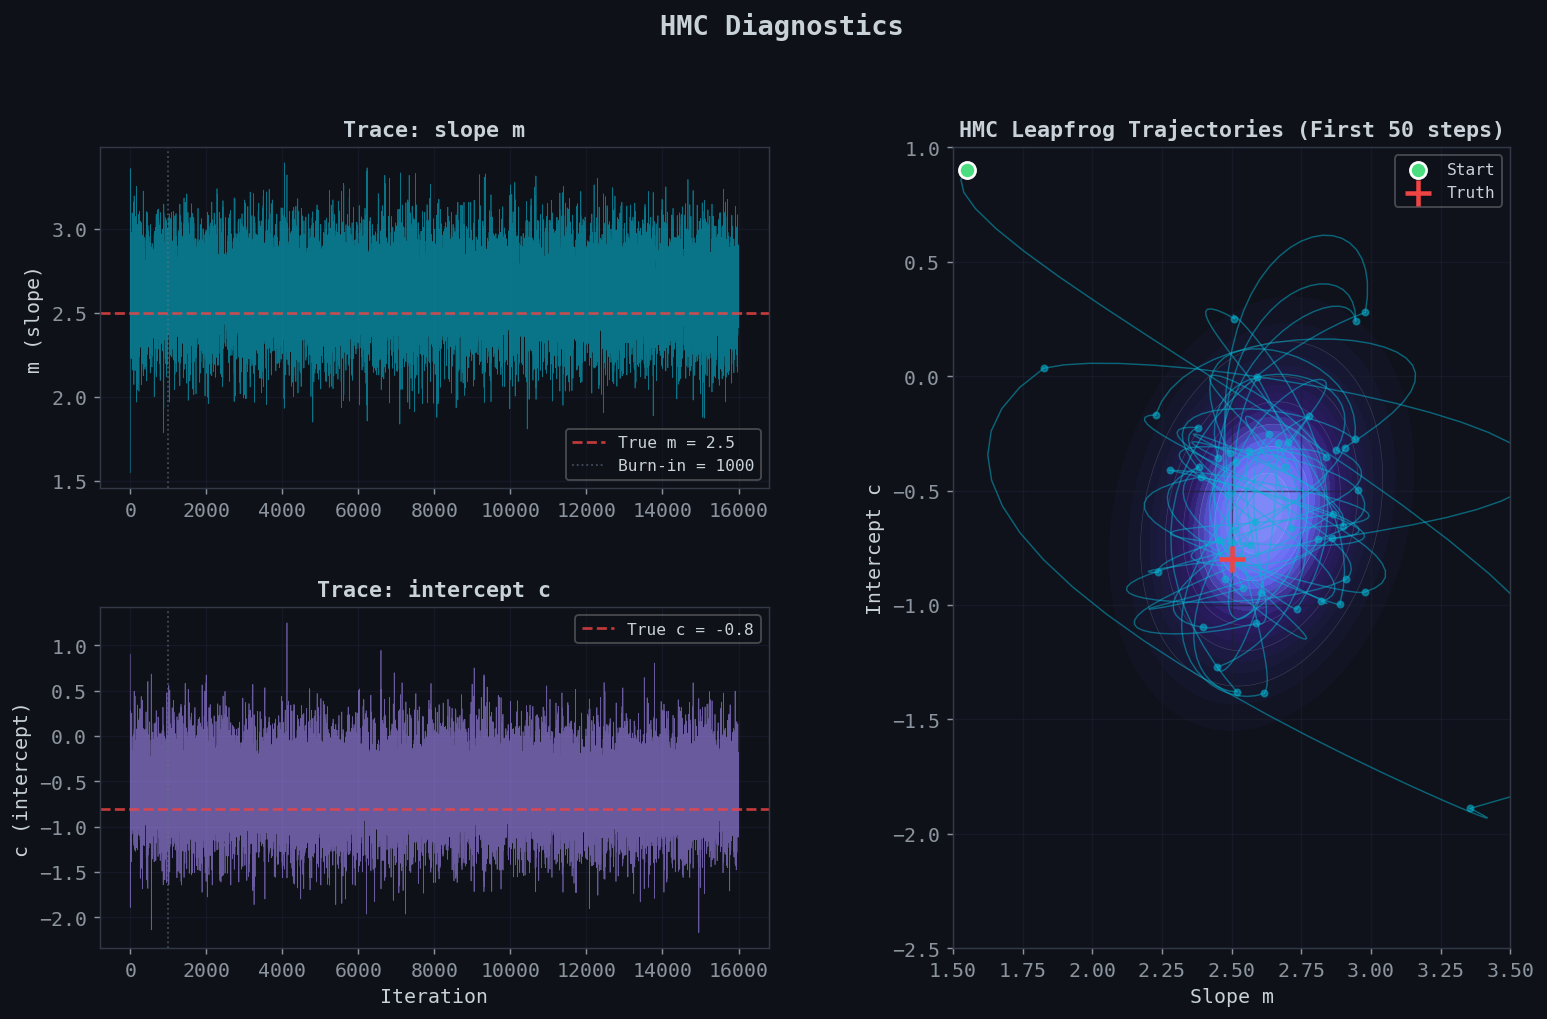

In [15]:
# ── HMC Diagnostics: Traces + Leapfrog Trajectories ───

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.2, 1], hspace=0.35, wspace=0.3)

# ── Trace plot: m ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(hmc_full[:, 0], color=CYAN, alpha=0.6, lw=0.4)
ax1.axhline(m_true, color=RED, ls='--', lw=1.5, alpha=0.8, label=f'True m = {m_true}')
ax1.axvline(burn_hmc, color=SLATE, ls=':', lw=1, alpha=0.6, label=f'Burn-in = {burn_hmc}')
ax1.set_ylabel('m (slope)')
ax1.set_title('Trace: slope m', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, framealpha=0.3)

# ── Trace plot: c ──
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(hmc_full[:, 1], color=PURPLE, alpha=0.6, lw=0.4)
ax2.axhline(c_true, color=RED, ls='--', lw=1.5, alpha=0.8, label=f'True c = {c_true}')
ax2.axvline(burn_hmc, color=SLATE, ls=':', lw=1, alpha=0.6)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('c (intercept)')
ax2.set_title('Trace: intercept c', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, framealpha=0.3)

# ── Leapfrog trajectories on posterior ──
ax3 = fig.add_subplot(gs[:, 1])
ax3.contourf(M, C, P_surf, levels=20,
             cmap=LinearSegmentedColormap.from_list('',
                   ['#0e1117', '#1a1a3e', '#2d1b69', '#6366f1', '#818cf8']))
ax3.contour(M, C, P_surf, levels=6, colors=WHITE, linewidths=0.3, alpha=0.2)

# Plot leapfrog trajectories
for traj, acc in hmc_trajs[:50]:
    color = CYAN if acc else RED
    alpha = 0.5 if acc else 0.3
    ax3.plot(traj[:, 0], traj[:, 1], color=color, alpha=alpha, lw=0.8)
    ax3.scatter(traj[-1, 0], traj[-1, 1], s=12, c=color, alpha=alpha, zorder=5)

ax3.scatter(hmc_full[0, 0], hmc_full[0, 1], marker='o', s=80,
            c=GREEN, edgecolors='white', linewidths=1.5, zorder=10, label='Start')
ax3.scatter([m_true], [c_true], marker='+', s=200, c=RED,
            linewidths=2.5, zorder=10, label='Truth')

ax3.set_xlabel('Slope m')
ax3.set_ylabel('Intercept c')
ax3.set_title('HMC Leapfrog Trajectories (First 50 steps)',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9, framealpha=0.3, loc='upper right')
ax3.set_xlim(m_grid[0], m_grid[-1])
ax3.set_ylim(c_grid[0], c_grid[-1])

fig.suptitle('HMC Diagnostics', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Autocorrelation & Effective Sample Size

Raw sample count doesn't tell the full story. Successive MCMC samples are **correlated**, so we need to quantify how quickly the chain "forgets" where it was.

### Autocorrelation function

For a chain $\{\theta_1, \theta_2, \ldots, \theta_N\}$ with mean $\bar{\theta}$ and variance $\hat{\sigma}^2$, the **normalised autocorrelation** at lag $k$ is:

$$\rho(k) = \frac{\hat{C}(k)}{\hat{C}(0)}$$

where the **autocovariance** at lag $k$ is:

$$\hat{C}(k) = \frac{1}{N - k} \sum_{i=1}^{N-k} \left(\theta_i - \bar{\theta}\right)\left(\theta_{i+k} - \bar{\theta}\right)$$

Note that $\rho(0) = 1$ by construction, and for an ideal i.i.d. sampler $\rho(k) = 0$ for all $k > 0$.

### Integrated autocorrelation time

The **integrated autocorrelation time** $\tau_{\rm int}$ captures the total correlation in a single number:

$$\tau_{\rm int} = 1 + 2\sum_{k=1}^{\infty} \rho(k)$$

This tells you how many raw samples it takes to get one effectively independent draw. The **effective sample size** is then:

$$\boxed{\text{ESS} = \frac{N}{\tau_{\rm int}} = \frac{N}{1 + 2\sum_{k=1}^{\infty} \rho(k)}}$$

A random-walk MH chain has $\tau_{\rm int} \gg 1$ (high autocorrelation, many wasted samples), while HMC's gradient-guided trajectories should give $\tau_{\rm int}$ much closer to 1.

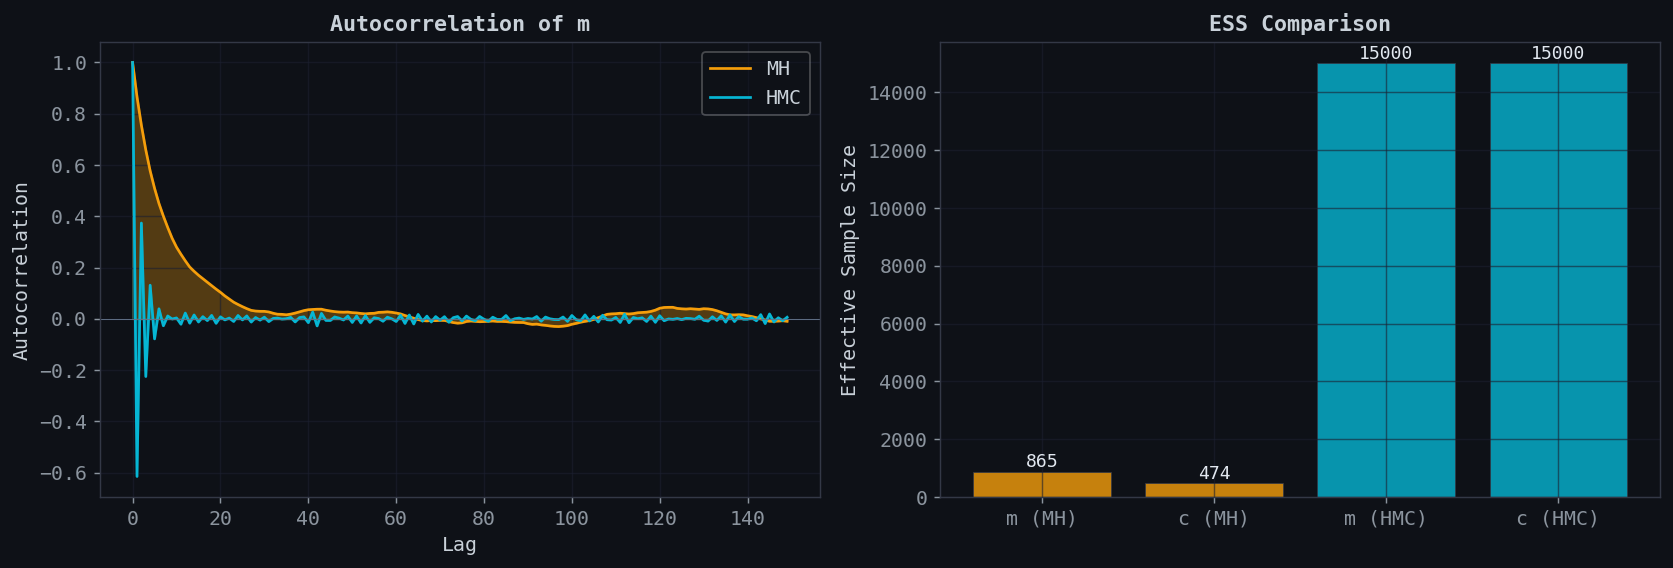


  ESS Comparison:
                               MH        HMC
  ──────────────────────────────────────────
  m (slope)                   865      15000
  c (intercept)               474      15000
  Raw samples               15000      15000
  ESS / sample (m)          5.77%    100.00%


In [16]:
def autocorrelation(chain, max_lag=200):
    """Compute normalised autocorrelation up to max_lag."""
    n = len(chain)
    mean = np.mean(chain)
    var  = np.var(chain)
    if var == 0:
        return np.zeros(max_lag)
    acf = np.array([
        np.mean((chain[:n-k] - mean) * (chain[k:] - mean)) / var
        for k in range(max_lag)
    ])
    return acf


def effective_sample_size(chain):
    """Estimate ESS using initial positive sequence estimator."""
    acf = autocorrelation(chain, max_lag=500)
    # Sum until autocorrelation goes negative
    running_sum = 0.0
    for k in range(1, len(acf)):
        if acf[k] < 0:
            break
        running_sum += acf[k]
    tau = 1 + 2 * running_sum
    return len(chain) / tau


# ── Plot autocorrelation comparison ────────────────────
max_lag = 150
mh_acf_m  = autocorrelation(mh_samples[:, 0], max_lag)
hmc_acf_m = autocorrelation(hmc_samples[:, 0], max_lag)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

lags = np.arange(max_lag)
ax1.fill_between(lags, 0, mh_acf_m, color=AMBER, alpha=0.3)
ax1.plot(lags, mh_acf_m, color=AMBER, lw=1.5, label='MH')
ax1.fill_between(lags, 0, hmc_acf_m, color=CYAN, alpha=0.3)
ax1.plot(lags, hmc_acf_m, color=CYAN, lw=1.5, label='HMC')
ax1.axhline(0, color=SLATE, lw=0.5)
ax1.set_xlabel('Lag')
ax1.set_ylabel('Autocorrelation')
ax1.set_title('Autocorrelation of m', fontsize=12, fontweight='bold')
ax1.legend(framealpha=0.3)

# ── ESS bar chart ──
ess_mh_m  = effective_sample_size(mh_samples[:, 0])
ess_mh_c  = effective_sample_size(mh_samples[:, 1])
ess_hmc_m = effective_sample_size(hmc_samples[:, 0])
ess_hmc_c = effective_sample_size(hmc_samples[:, 1])

labels = ['m (MH)', 'c (MH)', 'm (HMC)', 'c (HMC)']
values = [ess_mh_m, ess_mh_c, ess_hmc_m, ess_hmc_c]
colors = [AMBER, AMBER, CYAN, CYAN]

bars = ax2.bar(labels, values, color=colors, alpha=0.8, edgecolor='#333846', linewidth=0.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:.0f}', ha='center', va='bottom', fontsize=10, color=WHITE)

ax2.set_ylabel('Effective Sample Size')
ax2.set_title('ESS Comparison', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n  ESS Comparison:')
print(f'  {"":20s} {"MH":>10s} {"HMC":>10s}')
print(f'  {"─"*42}')
print(f'  {"m (slope)":20s} {ess_mh_m:10.0f} {ess_hmc_m:10.0f}')
print(f'  {"c (intercept)":20s} {ess_mh_c:10.0f} {ess_hmc_c:10.0f}')
print(f'  {"Raw samples":20s} {n_mh:10d} {n_hmc:10d}')
print(f'  {"ESS / sample (m)":20s} {ess_mh_m/n_mh:10.2%} {ess_hmc_m/n_hmc:10.2%}')

---
## 6. Corner Plot: The Full Picture

A **corner plot** (or triangle plot) shows the 1D marginal posteriors on the diagonal and the 2D joint distribution off-diagonal. This is the standard way to present MCMC results in astrophysics and cosmology.

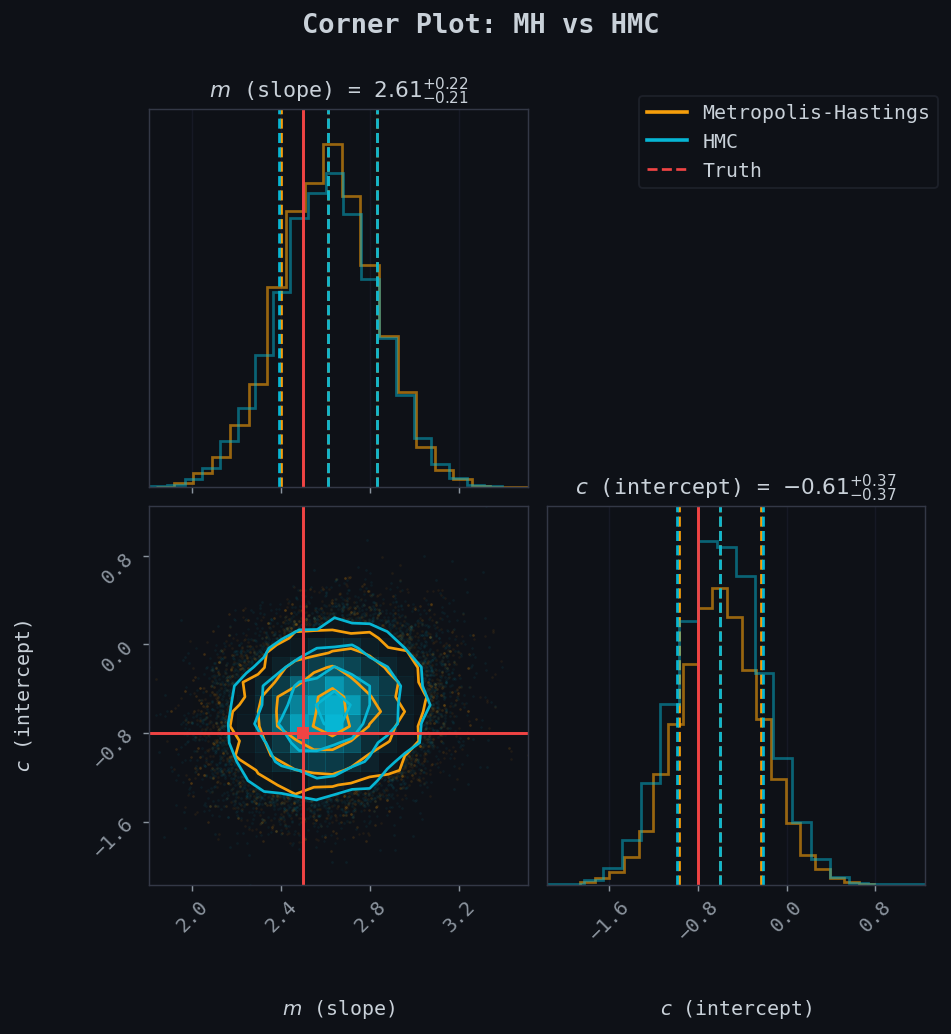

In [20]:
# ── Install corner if needed ────────────────────────────
try:
    import corner
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'corner', '-q'])
    import corner

# ── MH corner plot ─────────────────────────────────────
fig = corner.corner(
    mh_samples,
    labels=[r'$m$ (slope)', r'$c$ (intercept)'],
    truths=[m_true, c_true],
    truth_color=RED,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={'fontsize': 12},
    color=AMBER,
    hist_kwargs={'color': AMBER, 'alpha': 0.6, 'linewidth': 1.5},
    plot_datapoints=True,
    data_kwargs={'color': AMBER, 'alpha': 0.08, 'ms': 1.5},
    contourf_kwargs={'colors': 'none'},
    fig=plt.figure(figsize=(8, 8)),
)

# ── Overlay HMC on the same figure ─────────────────────
corner.corner(
    hmc_samples,
    labels=[r'$m$ (slope)', r'$c$ (intercept)'],
    truths=[m_true, c_true],
    truth_color=RED,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=False,
    color=CYAN,
    hist_kwargs={'color': CYAN, 'alpha': 0.5, 'linewidth': 1.5},
    plot_datapoints=True,
    data_kwargs={'color': CYAN, 'alpha': 0.08, 'ms': 1.5},
    contourf_kwargs={'colors': 'none'},
    fig=fig,
)

# ── Legend ──────────────────────────────────────────────
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=AMBER, lw=2, label='Metropolis-Hastings'),
    Line2D([0], [0], color=CYAN,  lw=2, label='HMC'),
    Line2D([0], [0], color=RED, ls='--', lw=1.5, label='Truth'),
]
fig.legend(handles=legend_handles, loc='upper right',
           fontsize=11, framealpha=0.4, edgecolor='#333846',
           bbox_to_anchor=(0.95, 0.95))

fig.suptitle('Corner Plot: MH vs HMC', fontsize=15,
             fontweight='bold', y=1.02)
plt.show()

---
## 7. Posterior Predictive: What the Model Thinks

Instead of drawing a single best-fit line, we draw **many lines** — each from a posterior sample — to visualise our uncertainty about the fit.

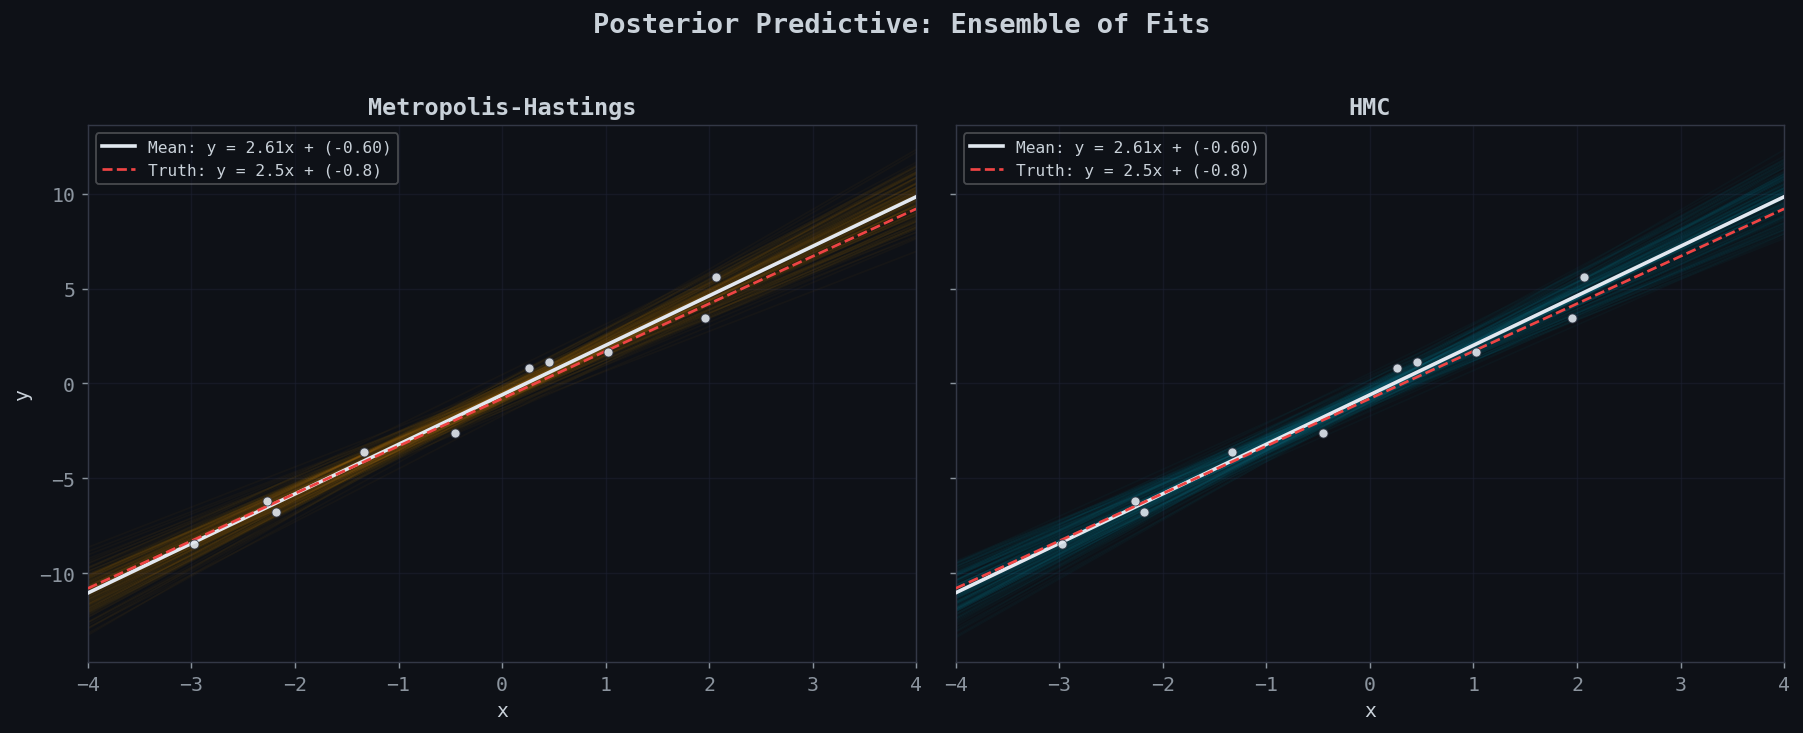

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

x_pred = np.linspace(-4, 4, 200)

for ax, samples, color, name in [
    (ax1, mh_samples, AMBER, 'Metropolis-Hastings'),
    (ax2, hmc_samples, CYAN, 'HMC')
]:
    # Draw 150 posterior lines
    idx = np.random.choice(len(samples), 150, replace=False)
    for k in idx:
        m_s, c_s = samples[k]
        ax.plot(x_pred, m_s * x_pred + c_s, color=color, alpha=0.03, lw=1)
    
    # Posterior mean line
    m_mean = np.mean(samples[:, 0])
    c_mean = np.mean(samples[:, 1])
    ax.plot(x_pred, m_mean * x_pred + c_mean, color=WHITE, lw=2,
            label=f'Mean: y = {m_mean:.2f}x + ({c_mean:.2f})', zorder=6)
    
    # True line
    ax.plot(x_pred, m_true * x_pred + c_true, color=RED, ls='--', lw=1.5,
            label=f'Truth: y = {m_true}x + ({c_true})', zorder=7)
    
    # Data
    ax.scatter(x_data, y_data, c=WHITE, s=25, zorder=8,
               edgecolors='#333846', linewidths=0.5, alpha=0.9)
    
    ax.set_xlabel('x')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.3, loc='upper left')
    ax.set_xlim(-4, 4)

ax1.set_ylabel('y')
fig.suptitle('Posterior Predictive: Ensemble of Fits',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Final Summary

### Parameter Estimates

In [22]:
def summary_stats(samples, name):
    """Compute summary statistics for a chain."""
    mean = np.mean(samples, axis=0)
    std  = np.std(samples, axis=0)
    q16  = np.percentile(samples, 16, axis=0)
    q50  = np.percentile(samples, 50, axis=0)
    q84  = np.percentile(samples, 84, axis=0)
    return {
        'name': name,
        'mean': mean, 'std': std,
        'q16': q16, 'q50': q50, 'q84': q84
    }

mh_stats  = summary_stats(mh_samples, 'Metropolis-Hastings')
hmc_stats = summary_stats(hmc_samples, 'HMC')

print('╔══════════════════════════════════════════════════════════════════════╗')
print('║                     POSTERIOR SUMMARY TABLE                        ║')
print('╠══════════════════════════════════════════════════════════════════════╣')
print(f'║  {"":15s} {"True":>8s} │ {"MH mean":>10s} {"MH std":>9s} │ {"HMC mean":>10s} {"HMC std":>9s} ║')
print(f'║  {"─"*63}  ║')
print(f'║  {"m (slope)":15s} {m_true:8.2f} │ {mh_stats["mean"][0]:10.3f} {mh_stats["std"][0]:9.3f} │ {hmc_stats["mean"][0]:10.3f} {hmc_stats["std"][0]:9.3f} ║')
print(f'║  {"c (intercept)":15s} {c_true:8.2f} │ {mh_stats["mean"][1]:10.3f} {mh_stats["std"][1]:9.3f} │ {hmc_stats["mean"][1]:10.3f} {hmc_stats["std"][1]:9.3f} ║')
print(f'║  {"─"*63}  ║')
print(f'║  {"Acceptance":15s} {"":8s} │ {mh_acc:10.1%} {"":9s} │ {hmc_acc:10.1%} {"":9s} ║')
print(f'║  {"ESS (m)":15s} {"":8s} │ {ess_mh_m:10.0f} {"":9s} │ {ess_hmc_m:10.0f} {"":9s} ║')
print(f'║  {"ESS (c)":15s} {"":8s} │ {ess_mh_c:10.0f} {"":9s} │ {ess_hmc_c:10.0f} {"":9s} ║')
print(f'║  {"Raw samples":15s} {"":8s} │ {n_mh:10d} {"":9s} │ {n_hmc:10d} {"":9s} ║')
print('╚══════════════════════════════════════════════════════════════════════╝')

print(f'\n  68% Credible Intervals:')
print(f'    MH  →  m ∈ [{mh_stats["q16"][0]:.3f}, {mh_stats["q84"][0]:.3f}]   c ∈ [{mh_stats["q16"][1]:.3f}, {mh_stats["q84"][1]:.3f}]')
print(f'    HMC →  m ∈ [{hmc_stats["q16"][0]:.3f}, {hmc_stats["q84"][0]:.3f}]   c ∈ [{hmc_stats["q16"][1]:.3f}, {hmc_stats["q84"][1]:.3f}]')

╔══════════════════════════════════════════════════════════════════════╗
║                     POSTERIOR SUMMARY TABLE                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                      True │    MH mean    MH std │   HMC mean   HMC std ║
║  ───────────────────────────────────────────────────────────────  ║
║  m (slope)           2.50 │      2.610     0.217 │      2.608     0.221 ║
║  c (intercept)      -0.80 │     -0.603     0.373 │     -0.599     0.390 ║
║  ───────────────────────────────────────────────────────────────  ║
║  Acceptance               │      74.4%           │      99.8%           ║
║  ESS (m)                  │        865           │      15000           ║
║  ESS (c)                  │        474           │      15000           ║
║  Raw samples              │      15000           │      15000           ║
╚══════════════════════════════════════════════════════════════════════╝

  68% Credible Intervals:
    MH  →  

---

## Key Takeaways

| | Metropolis-Hastings | HMC |
|---|---|---|
| **Gradient required?** | No | Yes |
| **Exploration style** | Random walk (diffusive) | Ballistic (follows geometry) |
| **Autocorrelation** | High (many correlated samples) | Low (near-independent samples) |
| **ESS per sample** | Low | High |
| **Tuning** | Proposal width only | Step size ε and leapfrog steps L |
| **Scales to high dimensions?** | Poorly ($\sim d^2$ scaling) | Well ($\sim d^{5/4}$ scaling) |

Both converge to the correct posterior — but HMC gets there with far fewer wasted samples. In high-dimensional problems (cosmological parameter inference, neural network posteriors), this efficiency gap becomes critical.

---
*Notebook by Sayan — MCMC for Bayesian inference*